# PEFT Fine-Tuning Comparison v2 — STL-10
## LoRA vs VeRA vs DoRA vs AdaLoRA vs IA3 vs TinyLoRA on STL-10

This is the STL-10 companion to the CIFAR-10 / CIFAR-100 / Food101 professor-spec notebooks —
identical methodology and fixes, run on a dataset with a very different scale characteristic:
STL-10 has far FEWER labeled training images than the others, which is worth understanding
before interpreting results.

1. Random seed = 42 everywhere, for reproducibility.
2. Full STL-10 labeled training split (5,000 images) split 80/20 into sub-train / validation.
3. 10 epochs for all experiments. LR grid = {0.001, 0.0005} compared for every method **except VeRA**, which uses a fixed LR = 0.01.
4. `target_modules = q_proj|v_proj` (attention only).
5. Model selection is done on the **validation** set; the reported number for each run is **test accuracy on the untouched STL-10 test split**, evaluated exactly once per run using the best-validation checkpoint.
6. Six methods: LoRA, VeRA, DoRA, AdaLoRA, IA3, TinyLoRA — plus a TinyLoRA high-LR run (0.01), carried over from the CIFAR experiments, since TinyLoRA showed a "stuck near random-guess loss" signature there that the same fix (raising LR ~20x) resolved for VeRA.
7. All test accuracies (plus val accuracy, F1, timing) are saved to JSON/Markdown for the report.

**What's substantively different about STL-10:**
- **Much less labeled training data.** STL-10 was designed for semi-supervised learning: only 5,000 labeled training images total (500/class) and 8,000 test images (800/class) — versus CIFAR's 50,000/10,000. There's also a 100,000-image *unlabeled* split, which this notebook does NOT use (our task is supervised PEFT comparison, consistent with the other notebooks; incorporating the unlabeled split would be a different research question).
- **After the 80/20 split, sub-training is only ~4,000 images (400/class) and validation ~1,000 images (100/class).** This is a meaningfully smaller and higher-variance training regime than any of the other three datasets — worth flagging explicitly when interpreting results, since some PEFT methods may behave differently with less data to fit.
- **96x96 fixed-size images** — higher resolution than CIFAR's 32x32, but like CIFAR (and unlike Food101), every image is the *same* fixed size. This means, unlike the Food101 notebook, we can keep CIFAR's original approach of resizing *after* batching (`resize_images()` performs a real resize here, not a no-op).
- **10 classes, but not the same classes as CIFAR-10** (airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck) — same count, different label semantics, so results are not directly label-comparable to CIFAR-10 despite both having 10 classes.
- **ImageNet normalization statistics** are used (same reasoning as Food101): STL-10 images are natural photos in the same broad domain as ImageNet, which the ViT backbone was pretrained on. There isn't a single universally-cited "STL-10 mean/std" the way there is for CIFAR, so ImageNet's well-documented statistics are the more defensible choice here rather than guessing at dataset-specific numbers.
- **Augmentation uses `RandomCrop(96, padding=12)`**, not CIFAR's `padding=4` — this specific padding value for STL-10 follows the augmentation recipe used in the Cutout paper (DeVries & Taylor, 2017) for this exact dataset, rather than reusing a padding value tuned for CIFAR's much smaller 32x32 images.

**Runtime note:** 12 total training runs, each 10 epochs -- but over a much smaller ~4,000-image sub-training set than the other notebooks, so each epoch is fast. STL-10's total download is small (~2.5GB) and images load from in-memory arrays like CIFAR (no per-image disk/JPEG decoding like Food101), so this notebook should run considerably faster end-to-end than the CIFAR-100 or Food101 versions. Results are saved incrementally after each run so a crash or timeout doesn't lose completed runs.


## 1. Setup and Installation

In [2]:
# Mount Google Drive (optional, for saving results)
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Verify GPU availability
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: NVIDIA L4
GPU memory: 23.66 GB


## 2. Imports, Global Config, and Reproducibility

In [4]:
import os
import json
import random
import copy
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import Resize
from transformers import AutoModel
from peft import (
    get_peft_model,
    LoraConfig,
    VeraConfig,
    AdaLoraConfig,
    IA3Config,
    TinyLoraConfig,
    PeftModel,
)
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# ---- Global config ----
SEED = 42
EPOCHS = 10
LR_GRID = [0.001, 0.0005]          # compared for every method except VeRA
VERA_LEARNING_RATE = 0.01          # VeRA needs a much larger LR (see prior fix); not part of the grid comparison
BATCH_SIZE = 64
TARGET_MODULES = r".*(q_proj|v_proj)$"
MODEL_NAME = 'google/vit-base-patch16-224-in21k'
NUM_CLASSES = 10                    # STL-10 has 10 classes (different label set from CIFAR-10, same count)
VAL_FRACTION = 0.20                # 80/20 split of the TRAINING set only

def set_seed(seed=SEED):
    """Reset every RNG so each run starts from an identical, reproducible state."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Seed: {SEED} | Epochs: {EPOCHS} | LR grid: {LR_GRID} | VeRA LR: {VERA_LEARNING_RATE}")


Using device: cuda
Seed: 42 | Epochs: 10 | LR grid: [0.001, 0.0005] | VeRA LR: 0.01


## 3. Data Preparation

Per the professor's instructions, adapted for STL-10:
- **Do not subsample.** Load the full STL-10 labeled training split (5,000 images: 500/class) and the full labeled test split (8,000 images: 800/class). The 100,000-image *unlabeled* split is intentionally not used here.
- Split the **training split only** into sub-train (80%) and validation (20%), stratified by class so each split has balanced classes, with `random_state=42` for reproducibility. With only 5,000 images total, this gives ~4,000 sub-train / ~1,000 validation images.
- The **test split is never split or touched** until final evaluation of the best checkpoint.
- Validation images use the *eval-time* transform (no random crop/flip) since validation should reflect eval-time conditions, not augmented training views.

**Difference from CIFAR:** STL-10 uses `split='train'` / `split='test'` (like Food101), not CIFAR's `train=True/False`. Class labels for stratification come from the dataset's public `.labels` attribute (a numpy array, populated at construction time -- not the same attribute name as Food101's private `._labels`).


In [5]:
# Define data transformations
# STL-10 images are natural photos (96x96, fixed size) -- closer to Food101's domain than
# CIFAR's, so we use ImageNet normalization statistics (consistent with the ViT's ImageNet-21k
# pretraining) rather than guessing at STL-10-specific statistics with no standard citation.
# Augmentation uses padding=12 (not CIFAR's padding=4), following the STL-10-specific recipe
# used in the Cutout paper (DeVries & Taylor, 2017) for this dataset's 96x96 images.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(96, padding=12),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Loading full STL-10 dataset (labeled train + test splits only, no subsetting)...")

# STL-10 uses split='train'/'test', not train=True/False like CIFAR.
# Images are fixed-size (96x96) like CIFAR, so -- unlike Food101 -- resizing to 224x224 can
# happen AFTER batching, via the resize_images() helper in Section 5, matching the CIFAR notebooks.
train_dataset_aug = datasets.STL10(root='./data', split='train', download=True, transform=transform_train)
train_dataset_noaug = datasets.STL10(root='./data', split='train', download=True, transform=transform_eval)
test_dataset = datasets.STL10(root='./data', split='test', download=True, transform=transform_eval)

# Stratified 80/20 split of the TRAINING split only, seeded for reproducibility.
# STL-10 exposes labels via the public `.labels` attribute (numpy array) -- fast, no image I/O.
all_indices = list(range(len(train_dataset_aug)))
all_labels = train_dataset_aug.labels
train_idx, val_idx = train_test_split(
    all_indices,
    test_size=VAL_FRACTION,
    random_state=SEED,
    shuffle=True,
    stratify=all_labels,
)

sub_train_dataset = Subset(train_dataset_aug, train_idx)     # 80%, augmented
val_dataset = Subset(train_dataset_noaug, val_idx)           # 20%, eval transform only
# test_dataset is used whole, untouched

print(f"Sub-train size : {len(sub_train_dataset)} (80% of {len(train_dataset_aug)} labeled train images)")
print(f"Validation size: {len(val_dataset)} (20% of {len(train_dataset_aug)} labeled train images)")
print(f"Test size      : {len(test_dataset)} (full labeled test split, untouched)")
print(f"Number of classes: {NUM_CLASSES}")
print("NOTE: this is a much smaller training set than CIFAR-10/100 or Food101 -- STL-10 was")
print("designed for semi-supervised learning; we're using only its labeled subset.")


Loading full STL-10 dataset (labeled train + test splits only, no subsetting)...


100%|██████████| 2.64G/2.64G [11:51<00:00, 3.71MB/s]


Sub-train size : 4000 (80% of 5000 labeled train images)
Validation size: 1000 (20% of 5000 labeled train images)
Test size      : 8000 (full labeled test split, untouched)
Number of classes: 10
NOTE: this is a much smaller training set than CIFAR-10/100 or Food101 -- STL-10 was
designed for semi-supervised learning; we're using only its labeled subset.


In [6]:
# Create data loaders
g = torch.Generator()
g.manual_seed(SEED)

# num_workers=2 (same as CIFAR, not Food101's 4): STL-10 images load from in-memory
# arrays like CIFAR, not per-image JPEG decoding from disk, so extra workers aren't needed.
train_loader = DataLoader(
    sub_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, generator=g
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")


Train batches: 63
Val batches  : 16
Test batches : 125


## 4. Model Setup with Classification Head

In [7]:
class STL10ClassificationModel(nn.Module):
    """Wrapper for ViT with classification head for STL-10"""
    def __init__(self, model_name=MODEL_NAME, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        self.hidden_size = self.backbone.config.hidden_size
        self.classifier = nn.Linear(self.hidden_size, num_classes)

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values)
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_output)
        return logits

def build_base_model():
    """Fresh, identically-initialized base model for each run (seed is reset by caller)."""
    model = STL10ClassificationModel(MODEL_NAME)
    return model.to(device)

print("Model class defined successfully!")


Model class defined successfully!


## 5. Training and Evaluation Functions

In [8]:
def resize_images(images, target_size=224):
    """Resize STL-10 images (96x96, fixed size) to target size for ViT.
    Unlike Food101 (variable-resolution photos, resized inside the transform pipeline before
    batching), STL-10 images are all the same size -- like CIFAR -- so resizing can happen
    here, after batching."""
    resizer = Resize((target_size, target_size))
    return resizer(images)

def train_epoch(model, loader, optimizer, criterion, device, epoch, total_epochs, scaler=None):
    """Train for one epoch. Uses AMP mixed precision when a GradScaler is provided."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs}", leave=False)
    for images, labels in pbar:
        images = resize_images(images, target_size=224).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        if scaler is not None:
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({'loss': total_loss / max(1, total // labels.size(0)), 'acc': 100 * correct / total})

    return total_loss / len(loader), 100 * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="Evaluating"):
    """Evaluate model on a given loader (used for both validation and test)."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc=desc, leave=False)
    for images, labels in pbar:
        images = resize_images(images, target_size=224).to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), accuracy, f1

def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

print("Training and evaluation functions defined!")


Training and evaluation functions defined!


## 6. Generalized Experiment Runner

One function drives every method/LR combination identically:
- resets the seed,
- trains for `EPOCHS` epochs, tracking **train** and **validation** metrics each epoch,
- keeps the model weights from the epoch with the **best validation accuracy** (in memory, `copy.deepcopy`'d state dict — avoids repeated disk I/O across 11 runs),
- after training, loads those best-validation weights and evaluates **once** on the untouched test set,
- (AdaLoRA only) calls `update_and_allocate` after every optimizer step, as its dynamic rank-pruning schedule requires.

In [9]:
def run_experiment(method_name, lr, peft_model, epochs=EPOCHS, is_adalora=False, use_amp=True, seed=SEED):
    """
    Train `peft_model` (already wrapped by get_peft_model) for `epochs` epochs.
    Model selection uses validation accuracy; final reported metric is test accuracy
    from the best-validation checkpoint, computed exactly once.
    """
    set_seed(seed)  # re-seed so data order / dropout / init noise is identical across LR variants

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(peft_model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda') if (use_amp and device.type == 'cuda') else None

    total_steps = epochs * len(train_loader)
    global_step = 0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_acc = -1.0
    best_state = None
    start_time = datetime.now()

    for epoch in range(epochs):
        # --- train ---
        peft_model.train()
        total_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"[{method_name} lr={lr}] Epoch {epoch+1}/{epochs}", leave=False)
        for images, labels in pbar:
            images = resize_images(images, target_size=224).to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            if scaler is not None:
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    logits = peft_model(images)
                    loss = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = peft_model(images)
                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()

            if is_adalora:
                # AdaLoRA's dynamic rank allocation must be updated every optimizer step
                peft_model.base_model.update_and_allocate(global_step)
            global_step += 1

            total_loss += loss.item()
            _, predicted = logits.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix({'loss': total_loss / max(1, total // labels.size(0)), 'acc': 100 * correct / total})

        train_loss, train_acc = total_loss / len(train_loader), 100 * correct / total

        # --- validate ---
        val_loss, val_acc, val_f1 = evaluate(peft_model, val_loader, criterion, device, desc="Validating")
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f"[{method_name} lr={lr}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% F1: {val_f1:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(peft_model.state_dict())
            print(f"  best checkpoint updated (val acc: {best_val_acc:.2f}%)")

    training_time = (datetime.now() - start_time).total_seconds()

    # Load best-validation weights, then evaluate on the TEST set exactly once
    peft_model.load_state_dict(best_state)
    test_loss, test_acc, test_f1 = evaluate(peft_model, test_loader, criterion, device, desc="Final test eval")

    print(f"[{method_name} lr={lr}] DONE | best val acc: {best_val_acc:.2f}% | "
          f"TEST acc: {test_acc:.2f}% | test F1: {test_f1:.4f} | time: {training_time:.1f}s")

    return {
        'history': history,
        'best_val_acc': best_val_acc,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'training_time_seconds': training_time,
    }


## 7. Method Configuration Factory

Builds a fresh base model + PEFT-wrapped model for a given `(method, lr)` pair. Each call re-seeds first, so every method starts from the identical base-model initialization.

In [10]:
def build_peft_model(method_name, epochs=EPOCHS):
    """Returns (peft_model, is_adalora_flag). Always builds a fresh base model first."""
    set_seed(SEED)
    base = build_base_model()

    if method_name == 'LoRA':
        cfg = LoraConfig(r=8, lora_alpha=16, target_modules=TARGET_MODULES, lora_dropout=0.1, bias='none')
        return get_peft_model(base, cfg), False

    elif method_name == 'VeRA':
        cfg = VeraConfig(r=8, target_modules=TARGET_MODULES)
        return get_peft_model(base, cfg), False

    elif method_name == 'DoRA':
        cfg = LoraConfig(r=8, lora_alpha=16, target_modules=TARGET_MODULES, lora_dropout=0.1,
                          bias='none', use_dora=True)
        return get_peft_model(base, cfg), False

    elif method_name == 'AdaLoRA':
        total_step = epochs * len(train_loader)
        cfg = AdaLoraConfig(
            init_r=12, target_r=8,                       # start at rank 12, prune down to 8
            target_modules=TARGET_MODULES,
            lora_alpha=16, lora_dropout=0.1, bias='none',
            tinit=int(0.1 * total_step),                  # warm-up steps before pruning starts
            tfinal=int(0.7 * total_step),                 # steps at which final rank is reached
            deltaT=10,
            total_step=total_step,
        )
        return get_peft_model(base, cfg), True

    elif method_name == 'IA3':
        cfg = IA3Config(target_modules=TARGET_MODULES, feedforward_modules=[])  # attention-only, no MLP targets
        return get_peft_model(base, cfg), False

    elif method_name == 'TinyLoRA':
        cfg = TinyLoraConfig(r=2, u=64, target_modules=TARGET_MODULES, projection_seed=SEED)
        return get_peft_model(base, cfg), False

    else:
        raise ValueError(f"Unknown method: {method_name}")


## 8. Run All Experiments

Per the spec: LoRA, DoRA, AdaLoRA, IA3, TinyLoRA are each run at **both** LR = 0.001 and LR = 0.0005 for comparison. VeRA is run once at its own LR = 0.01. Results are saved to disk after every single run, so a crash partway through the sweep doesn't lose completed work — just re-run this cell and it will pick up where the results file left off.

In [11]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 114.0 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [12]:
RESULTS_PATH = Path('/content/drive/MyDrive/PEFT_Results/all_results_stl10.json') if os.path.exists('/content/drive/MyDrive') else Path('./all_results_stl10.json')
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

# Load any previously-completed runs (resumability across sessions)
if RESULTS_PATH.exists():
    with open(RESULTS_PATH) as f:
        all_results = json.load(f)
    print(f"Resuming: {len(all_results)} run(s) already completed: {list(all_results.keys())}")
else:
    all_results = {}

# Build the full list of (method, lr) runs per the professor's spec
run_plan = []
for method in ['LoRA', 'DoRA', 'AdaLoRA', 'IA3', 'TinyLoRA']:
    for lr in LR_GRID:
        run_plan.append((method, lr))
run_plan.append(('VeRA', VERA_LEARNING_RATE))  # VeRA: single fixed LR, not part of the grid comparison

# CARRIED OVER FROM CIFAR EXPERIMENTS: TinyLoRA showed a "stuck near random-guess loss"
# signature there -- the same symptom VeRA had before its LR fix. TinyLoRA only learns a
# small vector projected through fixed random tensors (like VeRA), so the same fix is tested
# pre-emptively here too, rather than waiting to rediscover the same issue on STL-10.
TINYLORA_HIGH_LR = 0.01
run_plan.append(('TinyLoRA', TINYLORA_HIGH_LR))

print(f"Total runs planned: {len(run_plan)}")
for m, lr in run_plan:
    print(f"  {m:10s} lr={lr}")


Total runs planned: 12
  LoRA       lr=0.001
  LoRA       lr=0.0005
  DoRA       lr=0.001
  DoRA       lr=0.0005
  AdaLoRA    lr=0.001
  AdaLoRA    lr=0.0005
  IA3        lr=0.001
  IA3        lr=0.0005
  TinyLoRA   lr=0.001
  TinyLoRA   lr=0.0005
  VeRA       lr=0.01
  TinyLoRA   lr=0.01


In [13]:
for method_name, lr in run_plan:
    run_key = f"{method_name}_lr{lr}"
    if run_key in all_results and all_results[run_key].get('status') == 'success':
        print(f"Skipping {run_key} (already completed successfully)")
        continue

    print("\n" + "=" * 70)
    print(f"RUN: {run_key}")
    print("=" * 70)

    try:
        peft_model, is_adalora = build_peft_model(method_name, epochs=EPOCHS)
        trainable, total = count_parameters(peft_model)
        print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)")

        result = run_experiment(method_name, lr, peft_model, epochs=EPOCHS, is_adalora=is_adalora)
        result['method'] = method_name
        result['lr'] = lr
        result['trainable_params'] = trainable
        result['total_params'] = total
        result['status'] = 'success'

        del peft_model
        torch.cuda.empty_cache()

    except Exception as e:
        import traceback
        print(f"RUN FAILED: {run_key}\n{traceback.format_exc()}")
        result = {'method': method_name, 'lr': lr, 'status': 'failed', 'error': str(e)}

    all_results[run_key] = result
    with open(RESULTS_PATH, 'w') as f:
        json.dump(all_results, f, indent=2)
    print(f"Saved progress to {RESULTS_PATH} ({len(all_results)}/{len(run_plan)} runs done)")

print("\nAll runs complete (or already were).")



RUN: LoRA_lr0.001


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Trainable params: 294,912 / 86,691,850 (0.340%)


...

[TinyLoRA lr=0.01] Epoch 7/10 | Train Loss: 2.2365 Acc: 20.02% | Val Loss: 2.2398 Acc: 20.10% F1: 0.1775
  best checkpoint updated (val acc: 20.10%)


[TinyLoRA lr=0.01] Epoch 8/10 | Train Loss: 2.2318 Acc: 21.07% | Val Loss: 2.2359 Acc: 21.90% F1: 0.1926
  best checkpoint updated (val acc: 21.90%)


[TinyLoRA lr=0.01] Epoch 9/10 | Train Loss: 2.2314 Acc: 21.68% | Val Loss: 2.2347 Acc: 21.90% F1: 0.1967


[TinyLoRA lr=0.01] Epoch 10/10 | Train Loss: 2.2312 Acc: 20.93% | Val Loss: 2.2340 Acc: 21.80% F1: 0.1956


[TinyLoRA lr=0.01] DONE | best val acc: 21.90% | TEST acc: 20.82% | test F1: 0.1878 | time: 259.4s
Saved progress to /content/drive/MyDrive/PEFT_Results/all_results_stl10.json (12/12 runs done)

All runs complete (or already were).


## 9. Results Table — LR Comparison and Best-Per-Method Summary

In [14]:
# Full LR comparison table (professor explicitly asked to compare 0.001 vs 0.0005 vs your original choice)
print(f"{'Method':<10} {'LR':<10} {'Val Acc':<10} {'Test Acc':<10} {'Test F1':<10} {'Time (s)':<10} {'Status'}")
print("-" * 75)
for run_key, r in all_results.items():
    if r.get('status') != 'success':
        print(f"{r.get('method',''):<10} {r.get('lr',''):<10} {'--':<10} {'--':<10} {'--':<10} {'--':<10} FAILED")
        continue
    print(f"{r['method']:<10} {r['lr']:<10} {r['best_val_acc']:<10.2f} {r['test_acc']:<10.2f} "
          f"{r['test_f1']:<10.4f} {r['training_time_seconds']:<10.1f} success")

# Best LR per method, selected by TEST accuracy (per professor's instruction: comparison is
# made on test accuracy, not train/val accuracy)
print("\n" + "=" * 75)
print("BEST LR PER METHOD (selected by test accuracy)")
print("=" * 75)
best_per_method = {}
for run_key, r in all_results.items():
    if r.get('status') != 'success':
        continue
    m = r['method']
    if m not in best_per_method or r['test_acc'] > best_per_method[m]['test_acc']:
        best_per_method[m] = r

print(f"{'Method':<10} {'Best LR':<10} {'Val Acc':<10} {'Test Acc':<10} {'Test F1':<10}")
print("-" * 55)
for m, r in sorted(best_per_method.items(), key=lambda x: -x[1]['test_acc']):
    print(f"{m:<10} {r['lr']:<10} {r['best_val_acc']:<10.2f} {r['test_acc']:<10.2f} {r['test_f1']:<10.4f}")


Method     LR         Val Acc    Test Acc   Test F1    Time (s)   Status
---------------------------------------------------------------------------
LoRA       0.001      99.40      98.58      0.9858     277.5      success
LoRA       0.0005     98.80      98.38      0.9837     275.8      success
DoRA       0.001      99.20      98.72      0.9873     363.1      success
DoRA       0.0005     98.80      98.64      0.9864     363.3      success
AdaLoRA    0.001      98.70      98.81      0.9881     294.8      success
AdaLoRA    0.0005     97.60      97.85      0.9785     297.8      success
IA3        0.001      61.50      60.76      0.5976     252.0      success
IA3        0.0005     30.30      30.41      0.3019     266.3      success
TinyLoRA   0.001      23.10      21.55      0.1879     268.1      success
TinyLoRA   0.0005     19.90      19.91      0.1838     270.6      success
VeRA       0.01       94.90      94.62      0.9462     290.2      success
TinyLoRA   0.01       21.90      20.8

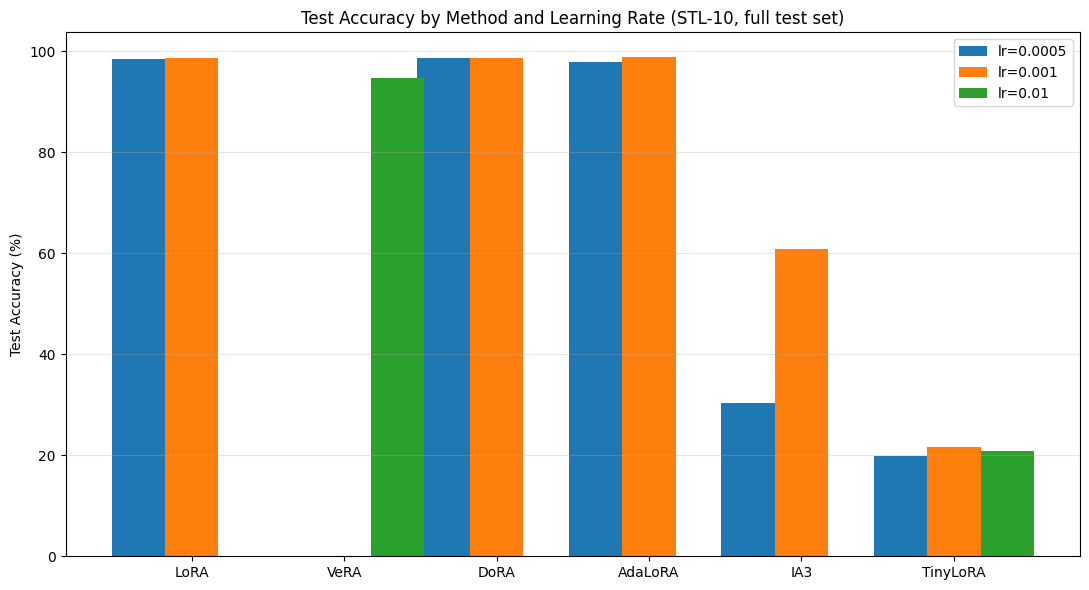

In [15]:
# Plot: test accuracy by method, grouped by LR (shows the requested LR comparison visually)
methods_order = ['LoRA', 'VeRA', 'DoRA', 'AdaLoRA', 'IA3', 'TinyLoRA']
lrs_present = sorted(set(r['lr'] for r in all_results.values() if r.get('status') == 'success'))

fig, ax = plt.subplots(figsize=(11, 6))
width = 0.35
x = np.arange(len(methods_order))

for i, lr in enumerate(lrs_present):
    vals = []
    for m in methods_order:
        key = f"{m}_lr{lr}"
        vals.append(all_results[key]['test_acc'] if key in all_results and all_results[key].get('status') == 'success' else np.nan)
    ax.bar(x + i * width - width * (len(lrs_present)-1) / 2, vals, width, label=f"lr={lr}")

ax.set_xticks(x)
ax.set_xticklabels(methods_order)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy by Method and Learning Rate (STL-10, full test set)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('peft_comparison_stl10.png', dpi=150)
plt.show()


## 10. Save Final Report

In [16]:
results_dir = Path('/content/drive/MyDrive/PEFT_Results') if os.path.exists('/content/drive/MyDrive') else Path('./PEFT_Results')
results_dir.mkdir(exist_ok=True, parents=True)

with open(results_dir / 'all_results_stl10.json', 'w') as f:
    json.dump(all_results, f, indent=2)

try:
    shutil.copy('peft_comparison_stl10.png', results_dir / 'peft_comparison_stl10.png')
except Exception:
    pass

report_lines = [
    "# PEFT Fine-Tuning Comparison Report v2 — STL-10",
    f"## Dataset: STL-10 (labeled subset) — sub-train {len(sub_train_dataset)} / val {len(val_dataset)} / test {len(test_dataset)}",
    f"## Model: {MODEL_NAME}",
    f"## Epochs: {EPOCHS} | Batch size: {BATCH_SIZE} | Seed: {SEED}",
    f"## Target modules: {TARGET_MODULES}",
    "",
    "### Full LR comparison (all runs)",
    "",
    "| Method | LR | Val Acc | Test Acc | Test F1 | Time (s) | Status |",
    "|---|---|---|---|---|---|---|",
]
for run_key, r in all_results.items():
    if r.get('status') == 'success':
        report_lines.append(f"| {r['method']} | {r['lr']} | {r['best_val_acc']:.2f}% | {r['test_acc']:.2f}% | "
                             f"{r['test_f1']:.4f} | {r['training_time_seconds']:.1f} | success |")
    else:
        report_lines.append(f"| {r.get('method','?')} | {r.get('lr','?')} | -- | -- | -- | -- | FAILED |")

report_lines += ["", "### Best LR per method (selected by test accuracy)", "",
                 "| Method | Best LR | Val Acc | Test Acc | Test F1 |", "|---|---|---|---|---|"]
for m, r in sorted(best_per_method.items(), key=lambda x: -x[1]['test_acc']):
    report_lines.append(f"| {m} | {r['lr']} | {r['best_val_acc']:.2f}% | {r['test_acc']:.2f}% | {r['test_f1']:.4f} |")

report = "\n".join(report_lines)
with open(results_dir / 'RESULTS_REPORT_stl10.md', 'w') as f:
    f.write(report)

print(report)
print(f"\nSaved to {results_dir}")


# PEFT Fine-Tuning Comparison Report v2 — STL-10
## Dataset: STL-10 (labeled subset) — sub-train 4000 / val 1000 / test 8000
## Model: google/vit-base-patch16-224-in21k
## Epochs: 10 | Batch size: 64 | Seed: 42
## Target modules: .*(q_proj|v_proj)$

### Full LR comparison (all runs)

| Method | LR | Val Acc | Test Acc | Test F1 | Time (s) | Status |
|---|---|---|---|---|---|---|
| LoRA | 0.001 | 99.40% | 98.58% | 0.9858 | 277.5 | success |
| LoRA | 0.0005 | 98.80% | 98.38% | 0.9837 | 275.8 | success |
| DoRA | 0.001 | 99.20% | 98.72% | 0.9873 | 363.1 | success |
| DoRA | 0.0005 | 98.80% | 98.64% | 0.9864 | 363.3 | success |
| AdaLoRA | 0.001 | 98.70% | 98.81% | 0.9881 | 294.8 | success |
| AdaLoRA | 0.0005 | 97.60% | 97.85% | 0.9785 | 297.8 | success |
| IA3 | 0.001 | 61.50% | 60.76% | 0.5976 | 252.0 | success |
| IA3 | 0.0005 | 30.30% | 30.41% | 0.3019 | 266.3 | success |
| TinyLoRA | 0.001 | 23.10% | 21.55% | 0.1879 | 268.1 | success |
| TinyLoRA | 0.0005 | 19.90% | 19.91% | 0.1838 |

## Notes on the less-common methods

- **AdaLoRA**: starts at rank 12 and dynamically prunes down to rank 8 during training (`init_r=12, target_r=8`), based on a learned importance score per singular value. Requires calling `update_and_allocate()` after every optimizer step, which is handled inside `run_experiment`. Because of the pruning schedule, its effective capacity is closer to LoRA rank 8 by the end of training, so scores should be broadly comparable to LoRA/DoRA.
- **IA3**: does not have a rank at all — it learns 3 rescaling vectors per targeted attention head (for query, value, and key internally), with no low-rank matrices. `feedforward_modules=[]` because our target list only includes attention (`q_proj`/`v_proj`), not the MLP (`fc1`/`fc2`); IA3 requires this argument to distinguish attention-style scaling from feedforward-style scaling.
- **TinyLoRA** (`r=2, u=64`): a 2026 PEFT method (Hugging Face `peft` PR #3024, "Learning to Reason in 13 Parameters") that reparameterizes a truncated-SVD-based low-rank update through a small trainable vector `v` projected via **fixed random tensors**, optionally with weight tying across layers/modules for extreme parameter counts. It was designed and validated primarily for RL-based LLM fine-tuning (GSM8K-style reasoning), not vision classification — so it's reasonable to expect it may underperform the other methods here; that's itself a legitimate, reportable finding rather than a bug, similar to how VeRA's tiny scaling vectors need a much larger LR to move at all.
- **peft version pin**: this notebook installs `peft>=0.19.1`. `TinyLoraConfig` was only added in a recent `peft` release — if `from peft import TinyLoraConfig` fails on your Colab instance, run `!pip install -U peft` and restart the runtime before re-running from the top.